<a href="https://colab.research.google.com/github/Govind-2004/Parallel_Project_NLP/blob/main/NLP_Parallel_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Loading Libraries

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 44.6 MB/s eta 0:00:00


In [4]:
!pip install wordcloud

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud
from collections import Counter

import string
# for stopword management
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords



# for lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from gensim.models import Word2Vec    # for Word2Vec

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional
from tensorflow.keras.layers import Dense, Dropout

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Reading data

In [6]:
# calling amazon,  yelp and imdb text data filepaths
filepath_amazon = "/content/drive/MyDrive/Colab Notebooks/Datasets /sentiment labelled sentences/amazon_cells_labelled.txt"
filepath_yelp = "/content/drive/MyDrive/Colab Notebooks/Datasets /sentiment labelled sentences/imdb_labelled.txt"
filepath_imdb = "/content/drive/MyDrive/Colab Notebooks/Datasets /sentiment labelled sentences/imdb_labelled.txt"

In [7]:
# converting the text data into data frames with splitting text and target columns
df_amazon = pd.read_csv(
    filepath_amazon,
    sep="\t",
    header=None,
    names=["text", "target"]
)

df_yelp = pd.read_csv(
    filepath_yelp,
    sep="\t",
    header=None,
    names=["text", "target"])

df_imdb = pd.read_csv(
    filepath_imdb,
    sep="\t",
    header=None,
    names=["text", "target"])

# combining the dataframes into a single dataframe
df_sentimental = pd.concat(
    [df_amazon, df_yelp, df_imdb],
    axis=0,
    ignore_index=True
)


# EDA

In [8]:
df_sentimental.head()

,text,target
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [9]:
df_sentimental.info()
# the target column is encoded and the column text is object data type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2496 non-null   object
 1   target  2496 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 39.1+ KB


In [10]:
df_sentimental.isna().sum()
# no missing values in any columns

,0
text,0
target,0


In [11]:
df_sentimental['target'].value_counts()
# both positive sentiment and negative sentiment classes are having similiar number of observations. Hence it is a balanced data

,count
target,
1,1272
0,1224


## Creating the word cloud

In [12]:
# combining all reviews into a single text
text = " ".join(df_sentimental["text"])

In [13]:
# creating the word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

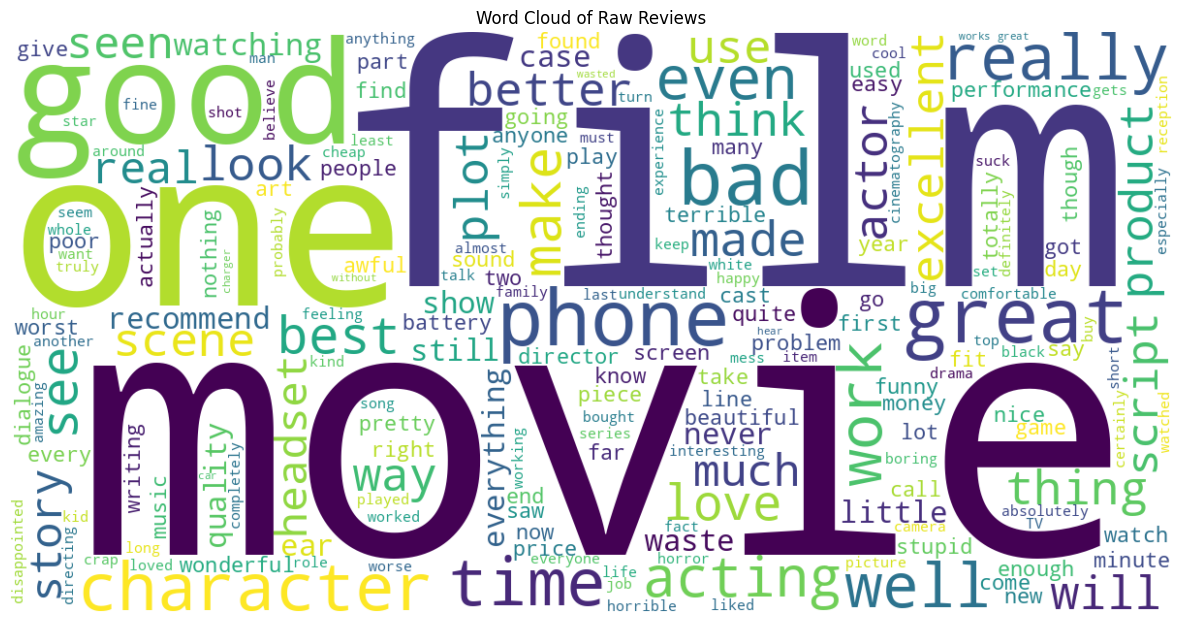

In [14]:
plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Raw Reviews")
plt.show()

Most frequent word is good. Words related to entertainment such as food, film, movie, phone, time is also frequently appeared.

## Finding the frquency of the words

In [15]:
# Split the text into words
words = text.split()

# Count the frequency of each word
word_counts = Counter(words)

# Display the 20 most frequent words
word_counts.most_common(20)

# before preprocessing commonly occuring words are majorly stopwords.

[('the', 1724),
 ('and', 1127),
 ('a', 1029),
 ('is', 884),
 ('of', 853),
 ('I', 811),
 ('to', 683),
 ('this', 551),
 ('The', 467),
 ('in', 466),
 ('it', 452),
 ('was', 445),
 ('that', 361),
 ('for', 312),
 ('with', 278),
 ('0', 276),
 ('movie', 264),
 ('1', 241),
 ('as', 222),
 ('on', 222)]

# Preprocessing

## Removing the punctuation

In [16]:

# displaying the predefined punctuations in string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [17]:

# replacing all punctuations with empty string
df_sentimental['text'] = df_sentimental['text'].str.replace(
        f'[{string.punctuation}]',
        '',
        regex=True
        # for finding anything matches the given pattern in string.punctuation.
    )

## Lowercasing

In [18]:
df_sentimental['text'] = df_sentimental['text'].str.lower()

## Managing stopwords

In [19]:
stop_words = set(stopwords.words('english'))
stopword_count = df_sentimental['text'].apply(
        lambda text: sum(word in stop_words for word in text.split())
    ).sum()
print(f"Total stop words: {stopword_count}")

# there are 16,735 stopwords

Total stop words: 18334


In [20]:
# Removing stop words to eliminate commonly occurring words that contribute little to distinguishing the sentiment of a review.
df_sentimental["text"] = df_sentimental["text"].apply(
    lambda text: " ".join(
        word for word in text.split() if word not in stop_words
    )
)

In [21]:
# verifying the stopwords are removed
stopword_count = df_sentimental["text"].apply(
    lambda text: sum(word in stop_words for word in text.split())
).sum()

print(f"Total stop words after removal: {stopword_count}")

# after removing stop words, remaining number of stopwords is 0

Total stop words after removal: 0


## Managing the numbers

In [22]:
count = df_sentimental['text'].str.contains(r'\d', regex=True).sum()
print(f"Total number of numbers in the text column: {count}")

Total number of numbers in the text column: 219


In [23]:
# inspecting the texts with numbers
df_sentimental[df_sentimental["text"].str.contains(r"\d", regex=True)].head(20)

,text,target
3,tied charger conversations lasting 45 minutesm...,0
12,two seperated mere 5 ft started notice excessi...,0
26,ive owned phone 7 months say best mobile phone...,1
35,need least 3 mins get phone book time first tu...,0
38,case great works fine 680,1
40,great camera thats 2mp pics nice clear great p...,1
57,even dropped phone stream submerged 15 seconds...,1
58,happy 510 complaints one regarding sound quali...,1
65,one big drawback mp3 player buttons phones fro...,0
69,device great several situations1,1


Numerical values were retained during preprocessing because they can contribute to sentiment classification by representing ratings or other sentiment-bearing information.

## Managing special characters

In [24]:
# counting the special characters
print(df_sentimental['text'].str.contains(r'[^A-Za-z0-9\s]', regex=True).sum())

22


In [25]:
# inspecting the texts with special characters
df_sentimental[df_sentimental["text"].str.contains(r'[^A-Za-z0-9\s]', regex=True)].head(20)

,text,target
1018,practically perfect  true masterpiece sea fau...,1
1019,structure film easily tightly constructed hist...,0
1121,ill even say  torture,0
1226,show made americans stupid full hatred clichés...,0
1271,cheap cheerless heist movie poor characterisat...,0
1297,forgot casting superb trond fausa aurvåg perfe...,1
1319,script bad bad  contains cheesiness unethical...,0
1359,lets start problemsthe acting especially lead...,0
1562,technically film well made impressive camerawo...,1
1569,tired clichés lazy writing come thick fast,0


In [26]:
# Removing special characters as they do not contribute to the sentiment of the text.
df_sentimental["text"] = df_sentimental["text"].apply(
    lambda text: re.sub(r"[^A-Za-z0-9\s]", "", text)
)

## Managing HTML tags

In [27]:
# Counting the number of texts containing HTML tags
html_count = df_sentimental['text'].str.contains(r'<.*?>', regex=True).sum()

print(f"{html_count} texts contain HTML tags.")

0 texts contain HTML tags.


## Tokenisation

In [28]:
df_sentimental['text_tokenized'] = df_sentimental['text'].str.split()

In [29]:
df_sentimental.head()

,text,target,text_tokenized
0,way plug us unless go converter,0,"[way, plug, us, unless, go, converter]"
1,good case excellent value,1,"[good, case, excellent, value]"
2,great jawbone,1,"[great, jawbone]"
3,tied charger conversations lasting 45 minutesm...,0,"[tied, charger, conversations, lasting, 45, mi..."
4,mic great,1,"[mic, great]"


## Lemmatization

Lemmatization was chosen because it converts words to their dictionary (base) forms, making them more suitable for Word2Vec vectorization.

In [30]:
# creating an object
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the tokenized text
df_sentimental['tokens_lemmatized'] = df_sentimental['text_tokenized'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

# Create a function that takes one input called tokens
#Considering tokens in each row; for each word in tokens, lemmatize it using the lemmatizer.

In [31]:
df_sentimental['text_lemmatized'] = df_sentimental['tokens_lemmatized'].apply(
    lambda tokens: " ".join(tokens)
)

In [32]:
df_sentimental


,text,target,text_tokenized,tokens_lemmatized,text_lemmatized
0,way plug us unless go converter,0,"[way, plug, us, unless, go, converter]","[way, plug, u, unless, go, converter]",way plug u unless go converter
1,good case excellent value,1,"[good, case, excellent, value]","[good, case, excellent, value]",good case excellent value
2,great jawbone,1,"[great, jawbone]","[great, jawbone]",great jawbone
3,tied charger conversations lasting 45 minutesm...,0,"[tied, charger, conversations, lasting, 45, mi...","[tied, charger, conversation, lasting, 45, min...",tied charger conversation lasting 45 minutesma...
4,mic great,1,"[mic, great]","[mic, great]",mic great
...,...,...,...,...,...
2491,got bored watching jessice lange take clothes,0,"[got, bored, watching, jessice, lange, take, c...","[got, bored, watching, jessice, lange, take, c...",got bored watching jessice lange take clothes
2492,unfortunately virtue films production work los...,0,"[unfortunately, virtue, films, production, wor...","[unfortunately, virtue, film, production, work...",unfortunately virtue film production work lost...
2493,word embarrassing,0,"[word, embarrassing]","[word, embarrassing]",word embarrassing
2494,exceptionally bad,0,"[exceptionally, bad]","[exceptionally, bad]",exceptionally bad


# Splitting data

In [33]:
X = df_sentimental['text_lemmatized']
y = df_sentimental['target']

In [34]:
X.head()

,text_lemmatized
0,way plug u unless go converter
1,good case excellent value
2,great jawbone
3,tied charger conversation lasting 45 minutesma...
4,mic great


In [35]:
y.value_counts()

,count
target,
1,1272
0,1224


In [36]:
# Splitting data for train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
# Check the sizes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1996,)
X_test : (500,)
y_train: (1996,)
y_test : (500,)


# TF-IDF

In [38]:
tf_idf_obj = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2),
    min_df=5
)

In [39]:
X_train_tf_idf = tf_idf_obj.fit_transform(X_train)
X_test_tf_idf = tf_idf_obj.transform(X_test)

## TF-IDF Logistic Regression

In [40]:
lr_tf_idf = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_tf_idf.fit(X_train_tf_idf, y_train)
y_pred_tf_idf_lr = lr_tf_idf.predict(X_test_tf_idf)

In [41]:
# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_tf_idf_lr))
print("Precision:", precision_score(y_test, y_pred_tf_idf_lr))
print("Recall   :", recall_score(y_test, y_pred_tf_idf_lr))
print("F1 Score :", f1_score(y_test, y_pred_tf_idf_lr))

Accuracy : 0.816
Precision: 0.8146718146718147
Recall   : 0.8274509803921568
F1 Score : 0.8210116731517509


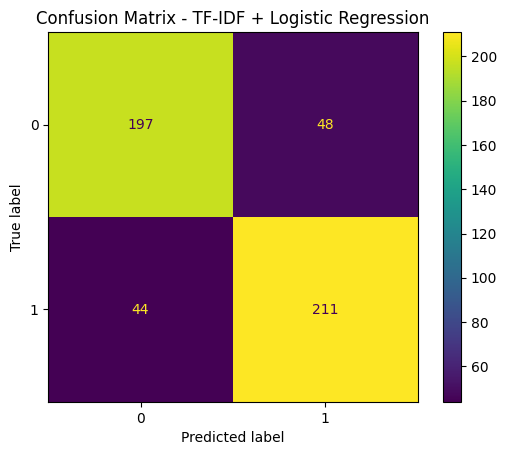

In [42]:
# Confusion matrix for tf-idf LR

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tf_idf_lr
)

plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.show()

## TF-IDF Linear SVM

In [43]:
svm_tf_idf = LinearSVC(random_state=42)
svm_tf_idf.fit(X_train_tf_idf, y_train)
y_pred_svm = svm_tf_idf.predict(X_test_tf_idf)

In [44]:
# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.85
Precision: 0.8461538461538461
Recall   : 0.8627450980392157
F1 Score : 0.8543689320388349


In [45]:
# Comparison of the two TF-IDF based models

tfidf_results = pd.DataFrame({
    'Model': [
        'TF-IDF + Logistic Regression',
        'TF-IDF + Linear SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_tf_idf_lr),
        accuracy_score(y_test, y_pred_svm)
    ],

    'Precision': [
        precision_score(y_test, y_pred_tf_idf_lr),
        precision_score(y_test, y_pred_svm)
    ],

    'Recall': [
        recall_score(y_test, y_pred_tf_idf_lr),
        recall_score(y_test, y_pred_svm)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_tf_idf_lr),
        f1_score(y_test, y_pred_svm)
    ]
})

tfidf_results

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.816,0.814672,0.827451,0.821012
1,TF-IDF + Linear SVM,0.850,0.846154,0.862745,0.854369


#Word2Vec

In [46]:
X_tokens = df_sentimental['tokens_lemmatized']

In [47]:
# Splitting data

X_train_tokens, X_test_tokens, y_train_w2v, y_test_w2v = train_test_split(
    X_tokens,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
print(X_train_tokens.shape)
print(X_test_tokens.shape)

(1996,)
(500,)


In [49]:
# Creating the model

word2vec_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=200,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    epochs=20,
    seed=42
)

In [50]:
def document_vector(tokens, model):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [51]:
# Convert training and testing vectors to tokens

X_train_w2v = np.array([
    document_vector(tokens, word2vec_model)
    for tokens in X_train_tokens
])

X_test_w2v = np.array([
    document_vector(tokens, word2vec_model)
    for tokens in X_test_tokens
])

In [52]:
print(X_train_w2v.shape)
print(X_test_w2v.shape)

(1996, 200)
(500, 200)


## Word2Vec Logistic Regression

In [53]:
lr_w2v = LogisticRegression(
    max_iter=1000,
    random_state=42)  # create model

In [54]:
lr_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v_lr = lr_w2v.predict(X_test_w2v)

In [55]:
# Evaluate
print("Accuracy :", accuracy_score(y_test_w2v, y_pred_w2v_lr))
print("Precision:", precision_score(y_test_w2v, y_pred_w2v_lr))
print("Recall   :", recall_score(y_test_w2v, y_pred_w2v_lr))
print("F1 Score :", f1_score(y_test_w2v, y_pred_w2v_lr))

Accuracy : 0.65
Precision: 0.6470588235294118
Recall   : 0.6901960784313725
F1 Score : 0.6679316888045541


## Word2Vec Linear SVM

In [56]:
svm_w2v = LinearSVC(random_state=42)

svm_w2v.fit(X_train_w2v, y_train_w2v)

y_pred_w2v_svm = svm_w2v.predict(X_test_w2v)

In [57]:
# Evaluate
print("Accuracy :", accuracy_score(y_test_w2v, y_pred_w2v_svm))
print("Precision:", precision_score(y_test_w2v, y_pred_w2v_svm))
print("Recall   :", recall_score(y_test_w2v, y_pred_w2v_svm))
print("F1 Score :", f1_score(y_test_w2v, y_pred_w2v_svm))

Accuracy : 0.69
Precision: 0.6785714285714286
Recall   : 0.7450980392156863
F1 Score : 0.7102803738317757


In [58]:
# Model comparison based on Word2Vec

In [59]:
w2v_results = pd.DataFrame({
    'Model': [
        'Word2Vec + Logistic Regression',
        'Word2Vec + Linear SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test_w2v, y_pred_w2v_lr),
        accuracy_score(y_test_w2v, y_pred_w2v_svm)
    ],

    'Precision': [
        precision_score(y_test_w2v, y_pred_w2v_lr),
        precision_score(y_test_w2v, y_pred_w2v_svm)
    ],

    'Recall': [
        recall_score(y_test_w2v, y_pred_w2v_lr),
        recall_score(y_test_w2v, y_pred_w2v_svm)
    ],

    'F1 Score': [
        f1_score(y_test_w2v, y_pred_w2v_lr),
        f1_score(y_test_w2v, y_pred_w2v_svm)
    ]
})

w2v_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Word2Vec + Logistic Regression,0.65,0.647059,0.690196,0.667932
1,Word2Vec + Linear SVM,0.69,0.678571,0.745098,0.710280


#Deep  Learning

In [60]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

In [61]:
# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [83]:
max_length = 100

In [62]:
# Padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen = 100,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen= 100,
    padding='post',
    truncating='post'
)

In [63]:
print("X_train:", X_train_pad.shape)
print("X_test :", X_test_pad.shape)

X_train: (1996, 100)
X_test : (500, 100)


In [64]:
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)

Vocabulary size: 3574


##LSTM

In [84]:
model = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

In [85]:
# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [86]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │       457,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 556,417 (2.12 MB)

 Trainable params: 556,417 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
# Training the model
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 347ms/step - accuracy: 0.5652 - loss: 0.6845 - val_accuracy: 0.7450 - val_loss: 0.6536
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.8108 - loss: 0.4859 - val_accuracy: 0.8175 - val_loss: 0.4028
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 181ms/step - accuracy: 0.9342 - loss: 0.1858 - val_accuracy: 0.8625 - val_loss: 0.4022
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.9737 - loss: 0.1060 - val_accuracy: 0.8650 - val_loss: 0.3862
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 180ms/step - accuracy: 0.9868 - loss: 0.0492 - val_accuracy: 0.8525 - val_loss: 0.5131
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.9912 - loss: 0.0401 - val_accuracy: 0.8625 - val_loss: 0.4569
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step - accuracy: 0.9944 - loss: 0.0226 - val_accuracy: 0.8725 - val_loss: 0.5369


In [88]:
print("Training accuracy:", history.history['accuracy'])
print("Validation accuracy:", history.history['val_accuracy'])

Training accuracy: [0.5651628971099854, 0.810776948928833, 0.9342105388641357, 0.9736841917037964, 0.9868420958518982, 0.9912280440330505, 0.9943609237670898]
Validation accuracy: [0.7450000047683716, 0.8174999952316284, 0.862500011920929, 0.8650000095367432, 0.8525000214576721, 0.862500011920929, 0.8725000023841858]


In [89]:
y_pred_prob = model.predict(X_test_pad)

y_pred_lstm = (y_pred_prob > 0.5).astype(int).flatten()

print("Accuracy :", accuracy_score(y_test, y_pred_lstm))
print("Precision:", precision_score(y_test, y_pred_lstm))
print("Recall   :", recall_score(y_test, y_pred_lstm))
print("F1 Score :", f1_score(y_test, y_pred_lstm))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step
Accuracy : 0.88
Precision: 0.862453531598513
Recall   : 0.9098039215686274
F1 Score : 0.8854961832061069


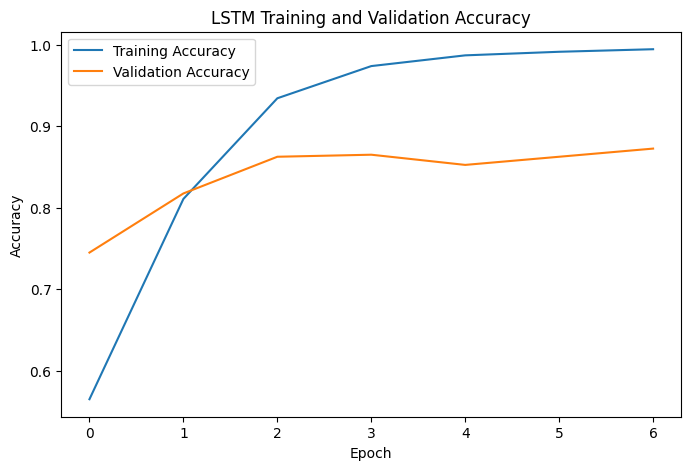

In [91]:
# Training vs Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

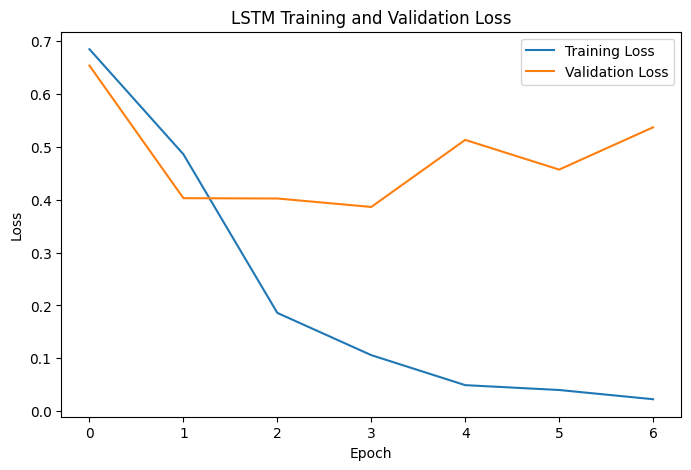

In [94]:
# Training vs Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

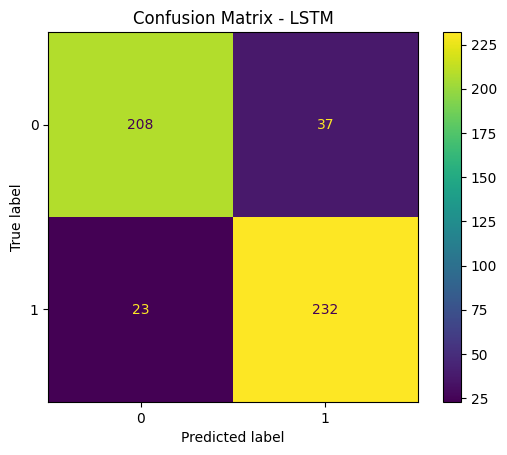

In [95]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lstm
)

plt.title("Confusion Matrix - LSTM")
plt.show()

In [98]:
print(classification_report(
    y_test,
    y_pred_lstm
))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87       245
           1       0.86      0.91      0.89       255

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



# Model Comparison

In [101]:
models = {
    "TF-IDF + Logistic Regression": (y_test, y_pred_tf_idf_lr),
    "TF-IDF + Linear SVM": (y_test, y_pred_svm),
    "Word2Vec + Logistic Regression": (y_test_w2v, y_pred_w2v_lr),
    "Word2Vec + Linear SVM": (y_test_w2v, y_pred_w2v_svm),
    "LSTM": (y_test, y_pred_lstm)
}

In [102]:
results = []

for model_name, (actual, predicted) in models.items():

    accuracy = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted)
    recall = recall_score(actual, predicted)
    f1 = f1_score(actual, predicted)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF + Logistic Regression,0.816,0.814672,0.827451,0.821012
1,TF-IDF + Linear SVM,0.850,0.846154,0.862745,0.854369
2,Word2Vec + Logistic Regression,0.650,0.647059,0.690196,0.667932
3,Word2Vec + Linear SVM,0.690,0.678571,0.745098,0.710280
4,LSTM,0.880,0.862454,0.909804,0.885496


In [103]:
# Best model
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Best F1 Score:", best_model["F1 Score"])

Best Model: LSTM
Best F1 Score: 0.8854961832061069
